# 0. Setup de zona de estudio

Genera el polígono AOI (Area Of Interest) de la zona activa definida en `config.py`,
disolviendo las comunas seleccionadas desde la cartografía censal 2024.

**Entrada:** `data/raw/Cartografía_censo2024_R13_Comunal.parquet` (52 comunas RM)

**Salida:** `data/raw/aoi_{zona}.gpkg` con dos capas:
- `aoi`: polígono disuelto (para clips, GEE, OSMnx)
- `comunas`: comunas individuales (para mapas y agregaciones)

Este AOI es el **input maestro** de los notebooks 0.1 (NDVI) y 0.2 (red peatonal),
y del filtro de manzanas censales en el pipeline principal.

---

In [4]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from config import ZONA, COMUNAS, FP_CARTO_COMUNAL, FP_AOI, CRS_GEO, CRS_PROJ

import geopandas as gpd
import matplotlib.pyplot as plt

print(f'Zona activa: {ZONA} ({len(COMUNAS)} comunas)')

Zona activa: suroriente (5 comunas)


## 1. Cargar cartografía comunal y filtrar zona

In [5]:
carto = gpd.read_parquet(FP_CARTO_COMUNAL)
# La geometría viene como 'SHAPE' (convención ESRI) en SIRGAS 2000 (EPSG:4674)
if 'SHAPE' in carto.columns:
    carto = carto.set_geometry('SHAPE')

zona_gdf = carto[carto['CUT'].isin(COMUNAS)].copy()
zona_gdf = zona_gdf.to_crs(CRS_GEO)

faltantes = set(COMUNAS) - set(zona_gdf['CUT'])
assert not faltantes, f'CUTs no encontrados en cartografía: {faltantes}'

print(f'Comunas encontradas: {len(zona_gdf)}/{len(COMUNAS)}')
print(zona_gdf[['CUT', 'COMUNA', 'PROVINCIA']].sort_values('CUT').to_string(index=False))

Comunas encontradas: 5/5
  CUT     COMUNA PROVINCIA
13110 LA FLORIDA  SANTIAGO
13113   LA REINA  SANTIAGO
13118      MACUL  SANTIAGO
13120      ÑUÑOA  SANTIAGO
13122  PEÑALOLÉN  SANTIAGO


## 2. Disolver en AOI único

In [6]:
# buffer(0) repara geometrías inválidas antes de disolver
zona_gdf['geometry_fix'] = zona_gdf.geometry.buffer(0)
zona_gdf = zona_gdf.set_geometry('geometry_fix')

# union_all() es geopandas >= 0.14.1; unary_union funciona en todas las versiones
aoi_geom = zona_gdf.geometry.unary_union
aoi = gpd.GeoDataFrame(
    {'zona': [ZONA], 'n_comunas': [len(COMUNAS)]},
    geometry=[aoi_geom], crs=CRS_GEO,
)

# Área en km² (proyección métrica)
area_km2 = aoi.to_crs(CRS_PROJ).geometry.area.iloc[0] / 1e6
print(f'AOI: {ZONA} | {len(COMUNAS)} comunas | {area_km2:,.1f} km²')
print(f'Tipo geometría: {aoi_geom.geom_type}')
print(f'Bounds (W, S, E, N): {aoi.total_bounds.round(4)}')

AOI: suroriente | 5 comunas | 177.6 km²
Tipo geometría: Polygon
Bounds (W, S, E, N): [-70.6316 -33.5702 -70.4371 -33.4289]


## 3. Guardar y visualizar

Guardado: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\raw\aoi_suroriente.gpkg


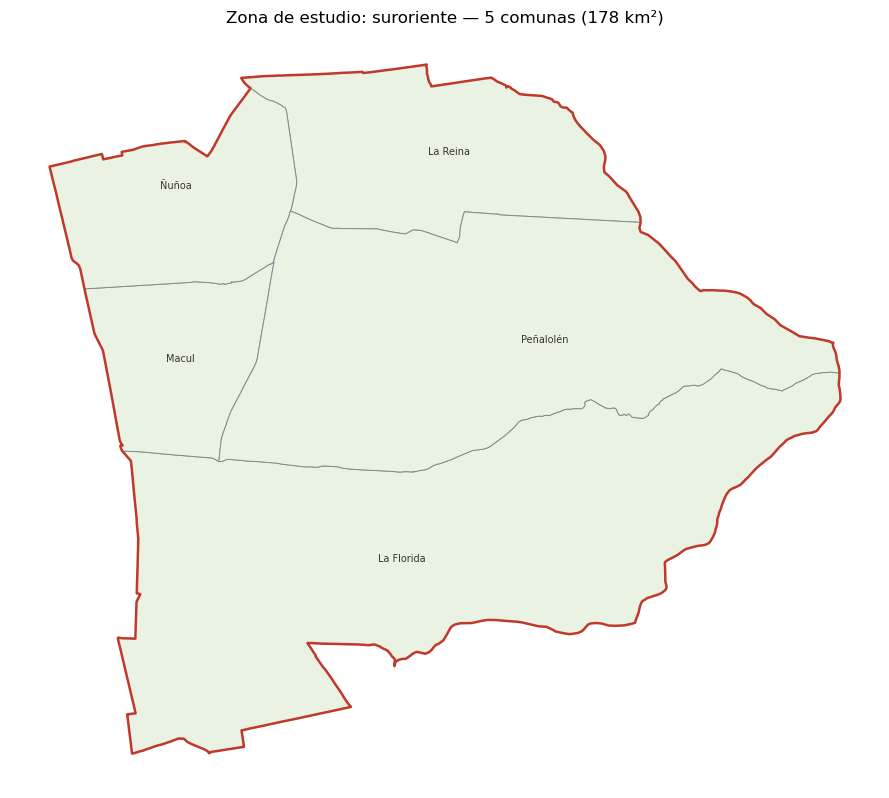

In [7]:
# Capa 1: AOI disuelto | Capa 2: comunas individuales de referencia
aoi.to_file(FP_AOI, layer='aoi', driver='GPKG')
comunas_export = zona_gdf[['CUT', 'COMUNA', 'PROVINCIA', 'geometry_fix']].rename(
    columns={'geometry_fix': 'geometry'}).set_geometry('geometry')
comunas_export.to_file(FP_AOI, layer='comunas', driver='GPKG')
print(f'Guardado: {FP_AOI}')

fig, ax = plt.subplots(figsize=(9, 9))
comunas_export.plot(ax=ax, facecolor='#eaf2e3', edgecolor='#7f8c8d', linewidth=0.7)
aoi.boundary.plot(ax=ax, color='#c0392b', linewidth=1.8)
for _, row in comunas_export.iterrows():
    pt = row.geometry.representative_point()
    ax.annotate(row['COMUNA'].title(), (pt.x, pt.y),
                ha='center', fontsize=7, color='#333')
ax.set_title(f'Zona de estudio: {ZONA} — {len(comunas_export)} comunas ({area_km2:,.0f} km²)')
ax.set_axis_off()
plt.tight_layout()
plt.show()